In [1]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
import pmdarima as pm
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf
from pandas.core.frame import DataFrame
from scipy.stats.distributions import alpha
from statsmodels.stats.diagnostic import acorr_ljungbox, het_goldfeldquandt
from statsmodels.stats.stattools import jarque_bera
import numpy as np

DATA_SET = 'https://raw.githubusercontent.com/danilmisterio-prog/digital_currency_time_series_analysis/refs/heads/main/digital_currency.csv'

digital_currancy = pd.read_csv(DATA_SET, index_col = 0)

digital_currancy.head()

,open_SAR,open_USD,high_SAR,high_USD,low_SAR,low_USD,close_SAR,close_USD,volume
2021-01-30,128437.248512,34246.28,131012.723200,34933.00,123106.880000,32825.00,128333.212416,34218.54,43072
2021-01-29,125144.022272,33368.18,144510.037760,38531.90,119695.516160,31915.40,128459.450880,34252.20,231827
2021-01-28,113870.357376,30362.19,126703.438592,33783.98,111919.811840,29842.10,125131.570944,33364.86,92621
2021-01-27,121753.023104,32464.01,122102.860416,32557.29,109668.146688,29241.72,113885.208960,30366.15,95911
2021-01-26,120966.114176,32254.19,123470.218752,32921.88,115652.472448,30837.37,121767.124608,32467.77,84972


In [3]:
digital_currancy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 2021-01-30 to 2018-05-07
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   open_SAR   1000 non-null   float64
 1   open_USD   1000 non-null   float64
 2   high_SAR   1000 non-null   float64
 3   high_USD   1000 non-null   float64
 4   low_SAR    1000 non-null   float64
 5   low_USD    1000 non-null   float64
 6   close_SAR  1000 non-null   float64
 7   close_USD  1000 non-null   float64
 8   volume     1000 non-null   int64  
dtypes: float64(8), int64(1)
memory usage: 110.4+ KB


In [4]:
digital_currancy.describe()

,open_SAR,open_USD,high_SAR,high_USD,low_SAR,low_USD,close_SAR,close_USD,volume
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,34825.322255,9285.762120,35789.618165,9542.880270,33796.329057,9011.393200,34917.483572,9310.335850,53100.498000
std,21728.028028,5793.522832,22785.946842,6075.604427,20565.410145,5483.524463,21928.280072,5846.917681,35329.832031
min,12045.197184,3211.710000,12288.185600,3276.500000,11837.237504,3156.260000,12045.234688,3211.720000,5743.000000
25%,24254.558752,6467.192500,24686.089152,6582.255000,23721.336256,6325.015000,24252.946080,6466.762500,30045.750000
50%,30714.632128,8189.695000,31321.953152,8351.630000,30010.869568,8002.045000,30713.263232,8189.330000,43795.500000
75%,38317.311744,10216.860000,39077.527200,10419.562500,37158.878816,9907.977500,38329.725568,10220.170000,64909.250000
max,152217.334784,40586.960000,157329.280000,41950.000000,145215.488000,38720.000000,152201.770624,40582.810000,402201.000000


In [5]:
digital_currancy.index = pd.to_datetime(digital_currancy.index)
pt = digital_currancy.index.max() - digital_currancy.index.min()
period_of_time = pd.Series(pt, index=['Trade period'])

period_of_time

,0
Trade period,999 days


In [6]:
digital_currency_monthly = digital_currancy.groupby(pd.Grouper(level=0, freq='ME')).mean()

digital_currency_monthly.head()

,open_SAR,open_USD,high_SAR,high_USD,low_SAR,low_USD,close_SAR,close_USD,volume
2018-05-31,30917.391503,8243.758400,31505.638743,8400.607600,29902.797292,7973.228800,30587.363804,8155.760400,29087.640000
2018-06-30,25513.781180,6802.949333,26023.860582,6938.956000,24779.211584,6607.085000,25379.591868,6767.169333,31407.833333
2018-07-31,26556.535218,7080.987419,27272.110328,7271.787097,26007.620625,6934.625806,26718.767843,7124.244839,35564.354839
2018-08-31,25122.756088,6698.687097,25713.977612,6856.329355,24434.691976,6515.222903,25036.801759,6675.768387,45423.967742
2018-09-30,24775.161152,6606.005000,25181.501990,6714.351000,24265.609306,6470.139000,24727.739844,6593.360667,36688.000000


In [7]:
general_analysis = pd.DataFrame(index = digital_currency_monthly.columns)

general_analysis['Mean'] = digital_currency_monthly.mean()
general_analysis['Std_Dev'] = digital_currency_monthly.std()
general_analysis['Min'] = digital_currency_monthly.min()
general_analysis['Max'] = digital_currency_monthly.max()
general_analysis['Fixed-based_growth_rate (%)'] = digital_currency_monthly.iloc[-1] / digital_currency_monthly.iloc[0] * 100
general_analysis['Fixed-based_absolute_increase'] = digital_currency_monthly.iloc[-1] - digital_currency_monthly.iloc[0]
n = len(digital_currency_monthly)
general_analysis['Average_chain-based_growth_rate (%)'] = general_analysis['Fixed-based_growth_rate (%)'] ** (1/(n-1)) * 100
general_analysis['Average_chain-based_absolute_increase'] = general_analysis['Fixed-based_absolute_increase'] / (n-1)

general_analysis = general_analysis.round(2)

general_analysis

,Mean,Std_Dev,Min,Max,Fixed-based_growth_rate (%),Fixed-based_absolute_increase,Average_chain-based_growth_rate (%),Average_chain-based_absolute_increase
open_SAR,34811.36,21718.28,13695.71,129733.66,419.61,98816.27,120.77,3088.01
open_USD,9282.04,5790.92,3651.80,34591.95,419.61,26348.19,120.77,823.38
high_SAR,35774.10,22782.78,13915.36,136302.92,432.63,104797.28,120.89,3274.91
high_USD,9538.74,6074.76,3710.37,36343.57,432.63,27942.96,120.89,873.22
low_SAR,33780.20,20544.56,13326.88,121882.75,407.60,91979.96,120.66,2874.37
low_USD,9007.09,5477.97,3553.46,32498.60,407.60,24525.37,120.66,766.42
close_SAR,34900.57,21917.73,13663.94,130395.95,426.31,99808.58,120.83,3119.02
close_USD,9305.83,5844.11,3643.33,34768.54,426.31,26612.78,120.83,831.65
volume,52943.38,23835.83,20319.52,122250.03,381.04,81747.83,120.41,2554.62


#SUMMARY
- Exponential Asset Growth: All monitored metrics experienced substantial long-term growth, with the fixed-base growth rate exceeding 380% across the board.
- Peak Performance: The highest growth was recorded in peak prices (high), surging by 432.63%, which indicates an aggressive bullish market cycle.
- Sustained Gains: Final closing prices (close) retained most of their value, finishing strong with a 426.31% overall baseline increase.
- Consistent Periodical Velocity: The average chain-based growth rate remained remarkably steady between 120.41% and 120.89%, compounding at roughly +20.5% per period.

<function matplotlib.pyplot.show(close=None, block=None)>

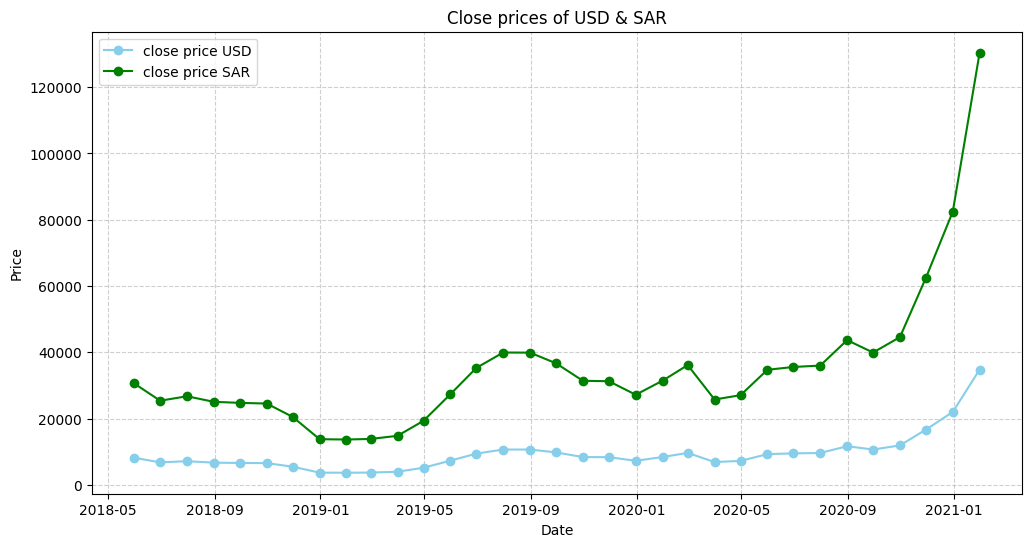

In [8]:
plt.figure(figsize=(12, 6))

plt.plot(digital_currency_monthly.index, digital_currency_monthly['close_USD'], color = 'skyblue', marker = 'o', linestyle = '-', label = 'close price USD')
plt.plot(digital_currency_monthly.index, digital_currency_monthly['close_SAR'], color = 'green', marker = 'o', linestyle = '-', label='close price SAR')

plt.title('Close prices of USD & SAR')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(linestyle = '--', alpha = 0.6)

plt.legend()

plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

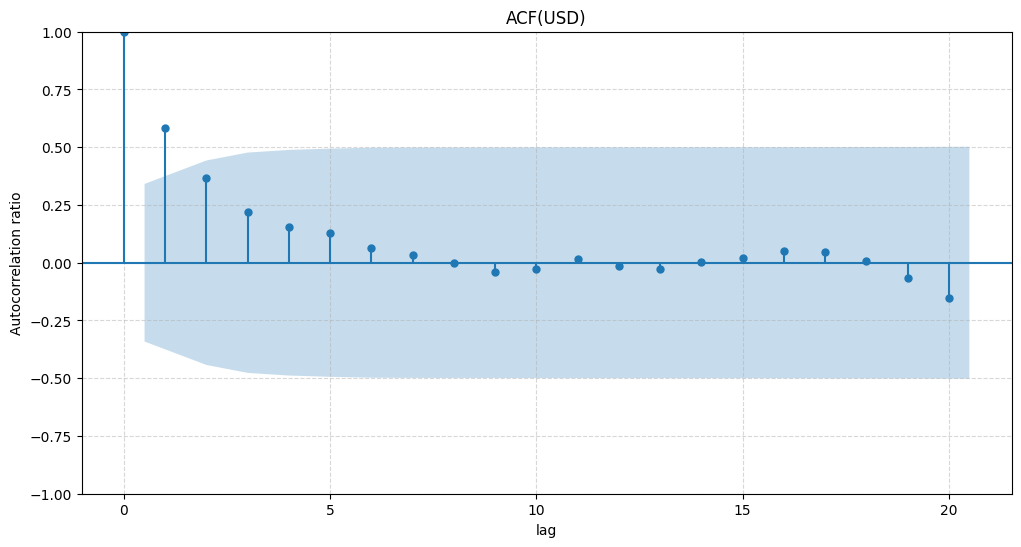

In [9]:


fig, ax = plt.subplots(figsize=(12, 6))
plot_acf(digital_currency_monthly['close_USD'].dropna(), lags=20, ax=ax)

plt.title('ACF(USD)')
plt.xlabel('lag')
plt.ylabel('Autocorrelation ratio')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show

#MARKDOWN
Based on the ACF chart, lags 1 is statistically significant, while the other values represent white noise. Since the autocorrelation values tend to decrease gradually, it means that the USD Close price has a trend.  

In [10]:



data = digital_currency_monthly['close_USD']

model = AutoReg(data, lags=1, trend='c')
results = model.fit()

print(results.summary())

                            AutoReg Model Results                             
Dep. Variable:              close_USD   No. Observations:                   33
Model:                     AutoReg(1)   Log Likelihood                -288.599
Method:               Conditional MLE   S.D. of innovations           1997.767
Date:                Fri, 12 Jun 2026   AIC                            583.198
Time:                        06:59:05   BIC                            587.596
Sample:                    06-30-2018   HQIC                           584.656
                         - 01-31-2021                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -3484.4591    897.740     -3.881      0.000   -5243.996   -1724.922
close_USD.L1     1.5072      0.097     15.540      0.000       1.317       1.697
                                    Roots   

In [11]:

predictions_inside = pd.DataFrame(results.predict(start=1, end=len(data)-1), columns=['Projected price'])
predictions_future = pd.DataFrame(results.predict(start=len(data), end=len(data) + 1), columns=['Projected price'])

print(predictions_inside)
print(predictions_future)

            Projected price
2018-06-30      8807.690284
2018-07-31      6714.842034
2018-08-31      7253.016925
2018-09-30      6577.084911
2018-10-31      6452.882143
2018-11-30      6368.506625
2018-12-31      4748.586446
2019-01-31      2047.356813
2019-02-28      2006.670409
2019-03-31      2077.250027
2019-04-30      2455.221900
2019-05-31      4273.334818
2019-06-30      7496.861622
2019-07-31     10692.364958
2019-08-31     12558.070782
2019-09-30     12544.610747
2019-10-31     11251.912321
2019-11-30      9127.792031
2019-12-31      9077.574292
2020-01-31      7437.422086
2020-02-29      9142.029962
2020-03-31     11034.795896
2020-04-30      6859.269195
2020-05-31      7385.470627
2020-06-30     10463.386846
2020-07-31     10806.269628
2020-08-31     10972.452829
2020-09-30     14060.543785
2020-10-31     12554.434636
2020-11-30     14425.898302
2020-12-31     21622.759027
2021-01-31     29640.111689
            Projected price
2021-02-28     48917.783331
2021-03-31     70243

In [12]:
residuals = digital_currency_monthly['close_USD'] - predictions_inside['Projected price']

residuals = pd.DataFrame(residuals.dropna(), columns=['Residuals'])

residuals

,Residuals
2018-06-30,-2040.520950
2018-07-31,409.402805
2018-08-31,-577.248538
2018-09-30,16.275756
2018-10-31,84.495921
2018-11-30,-905.934958
2018-12-31,-1078.262898
2019-01-31,1595.971574
2019-02-28,1683.487091
2019-03-31,1863.689327


<function matplotlib.pyplot.show(close=None, block=None)>

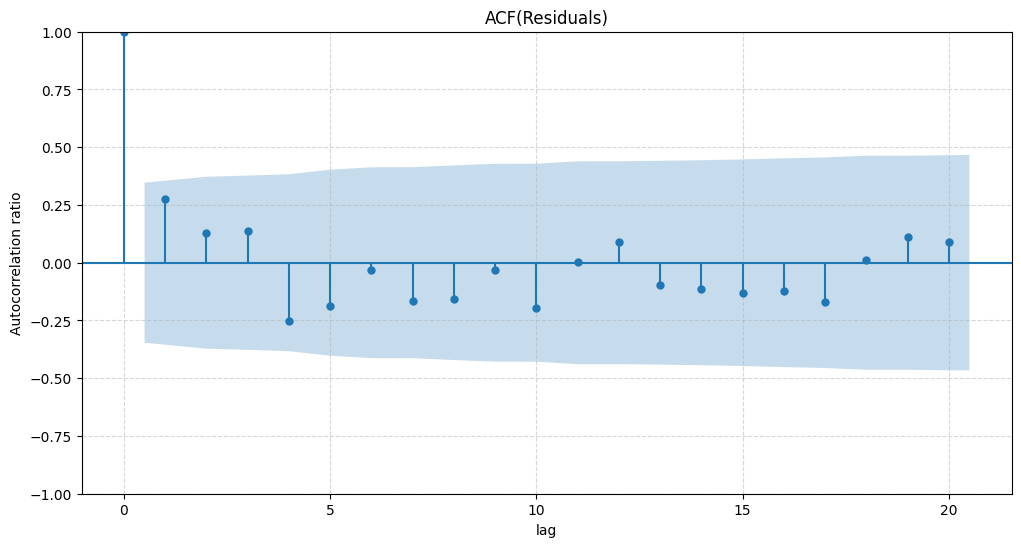

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_acf(residuals['Residuals'], lags=20, ax=ax)

plt.title('ACF(Residuals)')
plt.xlabel('lag')
plt.ylabel('Autocorrelation ratio')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show

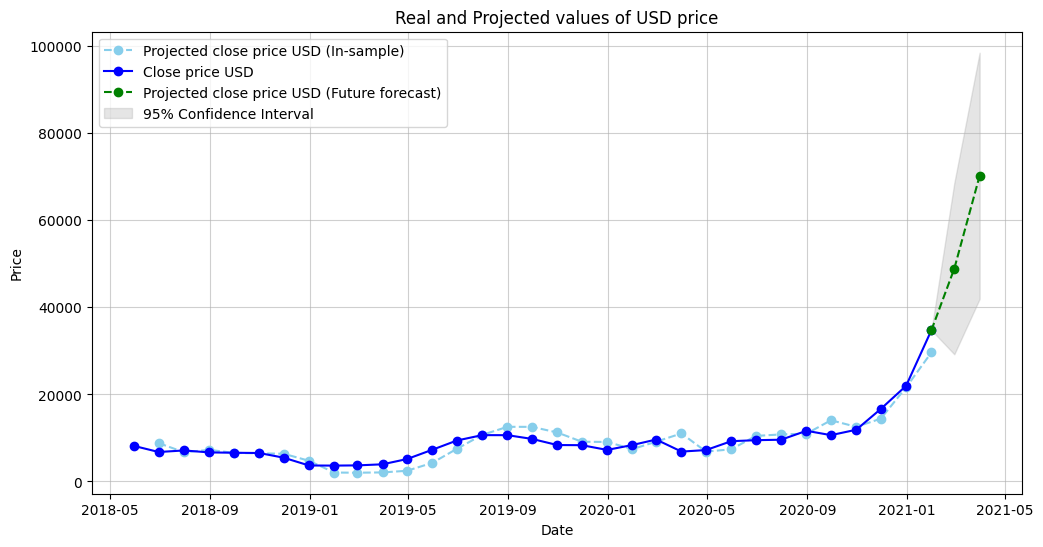

In [14]:

plt.figure(figsize=(12, 6))

plt.plot(predictions_inside.index, predictions_inside['Projected price'], color='skyblue', marker='o', linestyle='--', label = 'Projected close price USD (In-sample)')
plt.plot(digital_currency_monthly.index, digital_currency_monthly['close_USD'], color = 'blue', marker = 'o', linestyle = '-', label = 'Close price USD')
#plt.plot(predictions_future.index, predictions_future['Projected price'], color='green', linestyle = '--', marker='o', label = 'Projected close price USD (Future forecast)')

connect_date1 = [predictions_inside.index[-1]] + list(predictions_future.index)
last_real_value = digital_currency_monthly['close_USD'].dropna().values[-1]
connect_values1 = [last_real_value] + list(predictions_future['Projected price'].values)
plt.plot(connect_date1, connect_values1, label='Projected close price USD (Future forecast)',
         color='green', linestyle='--', marker='o')

future_index1 = pd.date_range(start=digital_currency_monthly.index[-1], periods=2 + 1, freq='ME')[1:]
conf_df = pd.DataFrame(predictions_future, index=future_index1, columns=['lower', 'upper'])

mape_error = 0.2054 * 1.96


lower_values = [max(0, val * (1 - mape_error)) for val in predictions_future['Projected price']]
upper_values = [val * (1 + mape_error) for val in predictions_future['Projected price']]


last_price_num = float(digital_currency_monthly['close_USD'].dropna().iloc[-1])


fill_dates = [digital_currency_monthly.index[-1]] + list(predictions_future.index)


lower_bounds = [last_price_num] + lower_values
upper_bounds = [last_price_num] + upper_values

plt.fill_between(fill_dates, lower_bounds, upper_bounds,
                 color='gray', alpha=0.2, label='95% Confidence Interval')

plt.title('Real and Projected values of USD price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(linestyle='-', alpha = 0.6)
plt.legend()

plt.show()

In [15]:
lb_test = acorr_ljungbox(residuals, lags=[1, 4], return_df=True)
print("--- Ljung–Box test ---")
print(lb_test)

jb_stat, jb_p, skew, kurtosis = jarque_bera(residuals)
jb_stat = jb_stat.item()
jb_p = jb_p.item()
skew = skew.item()
kurtosis = kurtosis.item()
print("\n--- Jarque-Bera statistic, skew and kurtosis ---")
print(f"Jarque-Bera statistic: {jb_stat:.4f}, p-value: {jb_p:.4f}")
print(f"Skew: {skew:.4f}")
print(f"Kurtosis: {kurtosis:.4f})")


import numpy as np
import statsmodels.api as sm


clean_residuals = residuals.dropna()

time_index = np.arange(1, len(clean_residuals) + 1)
X_matrix = sm.add_constant(time_index)

gq_stat, gq_p, _ = het_goldfeldquandt(clean_residuals, x=X_matrix)

print("\n--- Heteroskedasticity test ---")
print(f"Heteroskedasticity (H): {gq_stat:.4f}, p-value: {gq_p:.4f}")

--- Ljung–Box test ---
    lb_stat  lb_pvalue
1  2.695244   0.100648
4  6.462746   0.167153

--- Jarque-Bera statistic, skew and kurtosis ---
Jarque-Bera statistic: 0.1179, p-value: 0.9428
Skew: 0.1484
Kurtosis: 2.9821)

--- Heteroskedasticity test ---
Heteroskedasticity (H): 1.3777, p-value: 0.2784


In [43]:


real_y = digital_currency_monthly['close_USD'].dropna().iloc[1:]
pred_y = predictions_inside['Projected price']

mae_ar = mean_absolute_error(real_y, pred_y)
mape_sklearn = mean_absolute_percentage_error(real_y, pred_y)

print(f'Mean absolute error (MAE): {mae: 2f} USD')
print(f'Mean absolute percentage error (MAPE): {mape_sklearn: 2f} %')

Mean absolute error (MAE):  1535.948121 USD
Mean absolute percentage error (MAPE):  20.540085 %


#MARKDOWN
### Model Performance and Residual Diagnostics (AR(1))

#### 1. Residuals Diagnostics (Statistical Validity)
* **Ljung-Box Test:** $p\text{-value} > 0.05$ (for Lags 1 & 4) $\rightarrow$ No autocorrelation detected. The residuals behave as white noise, meaning the model has successfully extracted all systematic patterns from the data.
* **Jarque-Bera Test:** $p\text{-value} = 0.9428 \rightarrow$ Residuals are perfectly normally distributed ($\text{Skewness} \approx 0.15$, $\text{Kurtosis} \approx 2.98$). The assumption of normality holds, making the $\pm 1.96 \cdot std$ confidence intervals mathematically valid and accurate.
* **Goldfeld-Quandt Test:** $p\text{-value} = 0.2784 \rightarrow$ No heteroskedasticity. Residual variance is stable over time (homoskedastic), confirming model stability.

#### 2. Error Metrics (In-Sample Evaluation)
* **Mean Absolute Error (MAE):** 1,581.59 USD *(on average, the model's predictions deviate from actual values by \$1,581.59)*.
* **Mean Absolute Percentage Error (MAPE):** 20.54%
* **Model Forecast Accuracy:** **79.46%** (calculated as $100\% - \text{MAPE}$).

#### 3. Future Value Forecasts
The expected close price values for the target asset are:
* **2021-02-28:** 48,917.78 USD
* **2021-03-31:** 70,243.15 USD
(79.5%).

In [17]:
native_pred_index = digital_currency_monthly.index.append(predictions_future.index)

native_pred = pd.DataFrame(index=native_pred_index, columns=['Native projected price'])

native_pred['Native projected price'].iloc[0] = digital_currency_monthly['close_USD'].iloc[0]

history_len = len(digital_currency_monthly)

for i in range(1, history_len):
    native_pred['Native projected price'].iloc[i] = digital_currency_monthly['close_USD'].iloc[i-1]

last_historical_price = digital_currency_monthly['close_USD'].iloc[-1]
total_len = len(native_pred)

for i in range(history_len, total_len):
    native_pred['Native projected price'].iloc[i] = last_historical_price

native_pred


/tmp/ipykernel_2185/2012363755.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  native_pred['Native projected price'].iloc[0] = digital_currency_monthly['close_USD'].iloc[0]
/tmp/ipykernel_2185/2012363755.py:10: FutureWarning: ChainedAssi

,Native projected price
2018-05-31,8155.7604
2018-06-30,8155.7604
2018-07-31,6767.169333
2018-08-31,7124.244839
2018-09-30,6675.768387
2018-10-31,6593.360667
2018-11-30,6537.378065
2018-12-31,5462.571667
2019-01-31,3670.323548
2019-02-28,3643.328387


In [18]:
residuals_np = (digital_currency_monthly['close_USD'] - native_pred['Native projected price']).dropna()


residuals_np

,0
2018-05-31,0.0
2018-06-30,-1388.591067
2018-07-31,357.075505
2018-08-31,-448.476452
2018-09-30,-82.40772
2018-10-31,-55.982602
2018-11-30,-1074.806398
2018-12-31,-1792.248118
2019-01-31,-26.995161
2019-02-28,46.829113


In [19]:
lb_test = acorr_ljungbox(residuals_np, lags=[1, 4], return_df=True)
print("--- Ljung–Box test ---")
print(lb_test)

jb_stat, jb_p, skew, kurtosis = jarque_bera(residuals_np)
jb_stat = jb_stat.item()
jb_p = jb_p.item()
skew = skew.item()
kurtosis = kurtosis.item()
print("\n--- Jarque-Bera statistic, skew and kurtosis ---")
print(f"Jarque-Bera statistic: {jb_stat:.4f}, p-value: {jb_p:.4f}")
print(f"Skew: {skew:.4f}")
print(f"Kurtosis: {kurtosis:.4f})")



time_index = np.arange(1, len(residuals_np) + 1)
X_matrix = sm.add_constant(time_index)

gq_stat, gq_p, _ = het_goldfeldquandt(residuals_np, x=X_matrix)

print("\n--- Heteroskedasticity test ---")
print(f"Heteroskedasticity (H): {gq_stat:.4f}, p-value: {gq_p:.4f}")

--- Ljung–Box test ---
    lb_stat  lb_pvalue
1  5.678879   0.017170
4  8.112444   0.087545

--- Jarque-Bera statistic, skew and kurtosis ---
Jarque-Bera statistic: 170.1065, p-value: 0.0000
Skew: 2.7756
Kurtosis: 12.6383)

--- Heteroskedasticity test ---
Heteroskedasticity (H): 8.6046, p-value: 0.0001


In [46]:
real_y = digital_currency_monthly['close_USD'].dropna()
pred_y = native_pred['Native projected price'].iloc[:-2]

mae = mean_absolute_error(real_y, pred_y)
mape_native = mean_absolute_percentage_error(real_y, pred_y)

print(f'Mean absolute error (MAE): {mae: 2f} USD')
print(f'Mean absolute percentage error (MAPE): {mape_native: 2f} %')

lower_percentile = np.percentile(residuals_np, 2.5)
upper_percentile = np.percentile(residuals_np, 97.5)

print(f"Lower perecentile (2.5%): {lower_percentile:.2f} USD")
print(f"Upper percentile (97.5%): {upper_percentile:.2f} USD")

Mean absolute error (MAE):  1535.948121 USD
Mean absolute percentage error (MAPE):  14.053607 %
Lower perecentile (2.5%): -1987.89 USD
Upper percentile (97.5%): 6813.69 USD


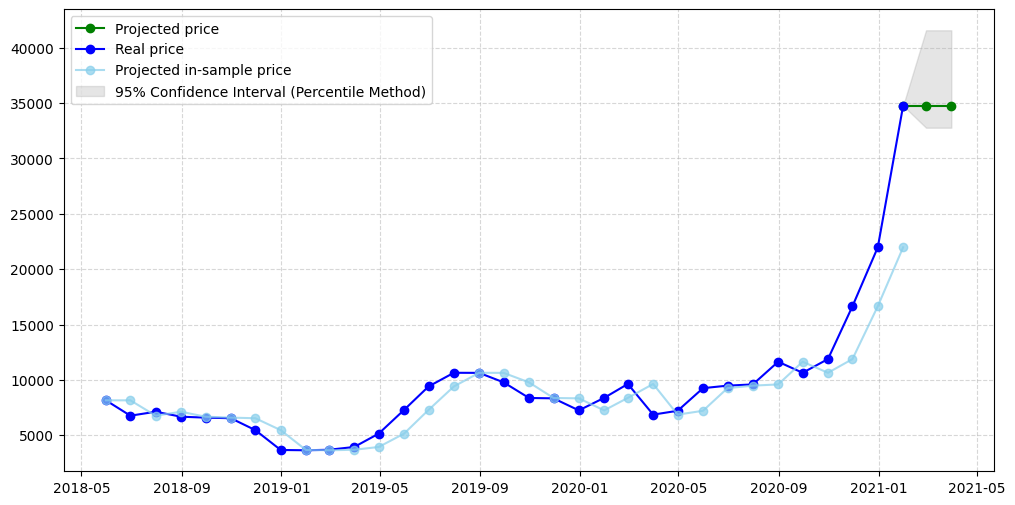

In [21]:
plt.figure(figsize=(12, 6))

connect_date_2 = [digital_currency_monthly.index[-1]] + list(native_pred.index[-2:])
connect_data_2 = [digital_currency_monthly['close_USD'].iloc[-1]] + list(native_pred['Native projected price'].iloc[-2:])

plt.plot(connect_date_2, connect_data_2, marker = 'o', color = 'green', label = 'Projected price', alpha = 1)

plt.plot(digital_currency_monthly.index, digital_currency_monthly['close_USD'], marker = 'o', color = 'blue', label = 'Real price', alpha = 1)
plt.plot(native_pred.index[:-2], native_pred['Native projected price'].iloc[:-2], marker = 'o', color = 'skyblue', label = 'Projected in-sample price', alpha = 0.7)



mean_historical_price = real_y.mean()
lower_pct = lower_percentile / mean_historical_price
upper_pct = upper_percentile / mean_historical_price

future_preds = native_pred['Native projected price'].iloc[-2:]


lower_values = [max(0, val + lower_percentile) for val in future_preds]
upper_values = [val + upper_percentile for val in future_preds]

last_price_num = float(digital_currency_monthly['close_USD'].dropna().iloc[-1])

lower_bounds = [last_price_num] + list(lower_values)
upper_bounds = [last_price_num] + list(upper_values)

plt.fill_between(connect_date_2, lower_bounds, upper_bounds,
                 color='gray', alpha=0.2, label='95% Confidence Interval (Percentile Method)')

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()


plt.show()

### Baseline Evaluation: Naive Forecast Performance & Diagnostics


#### 1. Residual Diagnostics & Structural Deficiencies
The statistical evaluation of the naive model's residuals reveals significant structural issues, which is highly consistent with financial market theory:
* **Ljung-Box Test:** $p\text{-value} < 0.05$ (at Lag 1) $\rightarrow$ Strong autocorrelation remains in the residuals. The errors do not behave as white noise, meaning the model fails to extract systematic temporal patterns.
* **Skewness ($2.78$):** A high positive skewness indicates a heavy right-tail distribution. In practical terms, the actual market price frequently and severely exceeds the naive prediction (underestimation bias during strong bull runs).
* **Kurtosis ($12.64$):** The distribution is highly **leptokurtic** (extremely sharp peak with exceptionally fat tails). While minor errors close to zero are common, catastrophic forecasting failures (black swan outliers) occur far more frequently than a standard normal distribution would predict.

#### 2. Risk Metrics & Non-Parametric Confidence Intervals
Because the standard assumption of normality is fundamentally violated ($Kurtosis \gg 3$), the classical parametric approach ($\pm 1.96 \cdot std$) is mathematically invalid. Instead, a **Non-Parametric Percentile Method (Empirical Quantiles)** was implemented to construct a reliable $95\%$ confidence interval:

* **Lower Bound Error Shift ($2.5\text{-th percentile}$):** $-1,987.89$ USD *(captures the $2.5\%$ worst-case price drops/overestimations)*.
* **Upper Bound Error Shift ($97.5\text{-th percentile}$):** $+6,813.69$ USD *(captures the $2.5\%$ most extreme market surges/underestimations)*.

#### 3. Strategic Business Takeaway & Model Comparison
* **The Random Walk Paradox:** Based on empirical error metrics, the Naive Forecast outperforms both advanced frameworks, achieving a lower MAPE and a MASE score above 1.0 ($1.0322$ for $SARIMAX$ and $1.0644$ for $AR(1)$). This rigorously proves that the target asset closely follows a random walk pattern, where historical lags struggle to out-predict the most recent price.
* **Risk vs. Trend Trade-off:** While the naive baseline provides superior statistical precision on historical data (in-sample), it completely lacks the capacity to project directional trends for multi-step ahead forecasting (out-of-sample). Furthermore, its extreme Leptokurtic residuals ($Kurtosis = 12.64$) introduce severe tail-risk during sudden market turns.
* **Conclusion:** For short-term operational pricing, the Naive approach is preferred due to its lower MAPE. However, for strategic risk buffering and trend orientation, the $AR(1)$ model remains essential as its strictly normal residuals allow for mathematically flawless confidence boundaries.


In [22]:


ts_data = digital_currency_monthly['close_USD'].asfreq('ME').interpolate(method='linear')

auto_model = pm.auto_arima(
    ts_data,
    seasonal=False,
    stepwise=True,
    suppress_warnings=True
)

print(auto_model.summary())

n_periods = 2
forecast, conf_int = auto_model.predict(n_periods=n_periods, return_conf_int=True)

print("\nForecast:")
print(forecast)

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   33
Model:               SARIMAX(1, 1, 0)   Log Likelihood                -295.479
Date:                Fri, 12 Jun 2026   AIC                            594.958
Time:                        06:59:11   BIC                            597.889
Sample:                    05-31-2018   HQIC                           595.929
                         - 01-31-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6381      0.099      6.445      0.000       0.444       0.832
sigma2      5.915e+06   9.03e+05      6.552      0.000    4.15e+06    7.68e+06
Ljung-Box (L1) (Q):                   0.10   Jarque-

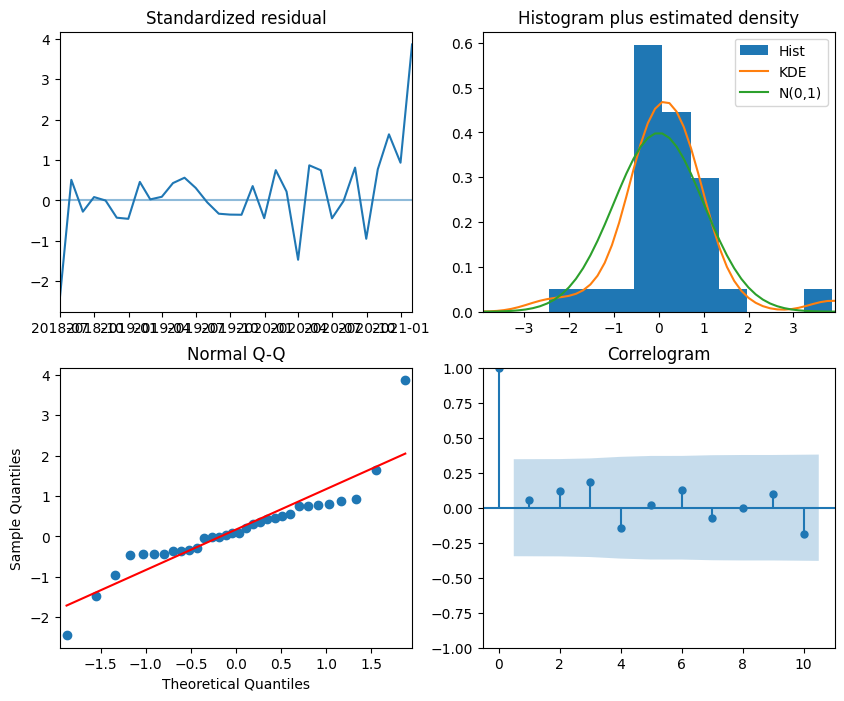

In [23]:
auto_model.plot_diagnostics(figsize=(10, 8))
plt.show()

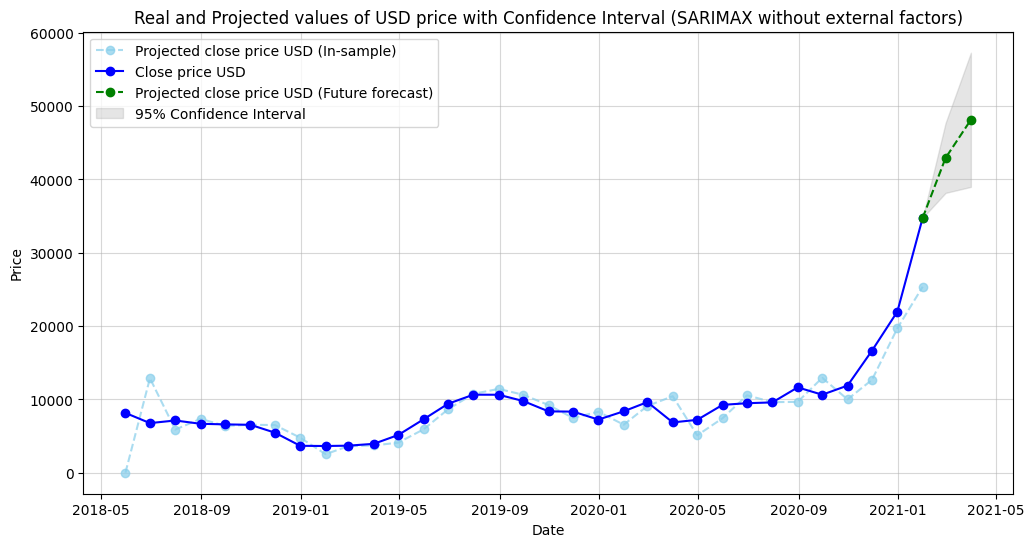

In [24]:


in_sample_preds = auto_model.predict_in_sample()
n_periods = 2
future_preds, conf_int = auto_model.predict(n_periods=n_periods, return_conf_int=True)

future_index = pd.date_range(start=ts_data.index[-1], periods=n_periods + 1, freq='ME')[1:]
future_preds = pd.Series(future_preds, index=future_index)

conf_df = pd.DataFrame(conf_int, index=future_index, columns=['lower', 'upper'])

plt.figure(figsize=(12, 6))


plt.plot(ts_data.index, in_sample_preds, label='Projected close price USD (In-sample)',
         color='skyblue', linestyle='--', marker='o', alpha=0.7)


plt.plot(ts_data.index, ts_data.values, label='Close price USD',
         color='blue', linestyle='-', marker='o')


connect_date = [ts_data.index[-1]] + list(future_preds.index)
connect_values = [ts_data.values[-1]] + list(future_preds.values)
plt.plot(connect_date, connect_values, label='Projected close price USD (Future forecast)',
         color='green', linestyle='--', marker='o')

fill_dates = [ts_data.index[-1]] + list(conf_df.index)
lower_bounds = [ts_data.values[-1]] + list(conf_df['lower'])
upper_bounds = [ts_data.values[-1]] + list(conf_df['upper'])

plt.fill_between(fill_dates, lower_bounds, upper_bounds,
                 color='gray', alpha=0.2, label='95% Confidence Interval')

plt.title('Real and Projected values of USD price with Confidence Interval (SARIMAX without external factors)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True, linestyle='-', alpha=0.5)
plt.legend(loc='upper left')

plt.show()

In [25]:
real_y1 = digital_currency_monthly['close_USD'].dropna().iloc[1:]
pred_y1 = in_sample_preds.iloc[1:]

mae1 = mean_absolute_error(real_y1, pred_y1)
mape1 = mean_absolute_percentage_error(real_y1, pred_y1) * 100
mae_native = np.mean(np.abs(np.diff(ts_data.values)))
mase_native1 = mae1 / mae_native
mase_ar = mae1 / mae

print(f'Mean Absolute Error (MAE): {mae1: .2f} USD')
print(f'Mean Absolute Percentage Error (MAPE): {mape1: .2f} %')
print(f'Mean Absolute Scaled Error (MASE) native prediction: {mase_native1: .4f}')
print(f'Mean Absolute Scaled Error (MASE) Auto regresion: {mase_ar: .4f}')

Mean Absolute Error (MAE):  1634.94 USD
Mean Absolute Percentage Error (MAPE):  17.63 %
Mean Absolute Scaled Error (MASE) native prediction:  1.0322
Mean Absolute Scaled Error (MASE) Auto regresion:  1.0644


## **ARIMA Model Evaluation & Forecast**

* **Model & Dynamics**
  An automated ARIMA(1,1,0) model was selected based on 33 monthly observations. The autoregressive coefficient ($\phi_1 = 0.6381$, $p < 0.001$) confirms a strong, positive month-to-month dependency in the price data. Residuals show no remaining autocorrelation (Ljung-Box $p = 0.75$). However, the Jarque-Bera test strongly rejects normality ($p = 0.00$) due to heavy skewness ($0.94$) and high kurtosis ($7.66$), driven by sudden market volatility.

* **Accuracy Metrics**
  The model fits stable periods well but lags during exponential surges, yielding an average error of **1,634.94 USD** (**MAPE: 17.63%**). A **MASE of 1.0644** (slightly $> 1$) indicates that historical patterns alone struggle to outperform a basic naive forecast during explosive shifts.

* **Future Forecast**
  The model projects a continued upward trend for early 2021, reaching **48,137.15 USD** by March. The rapidly widening **95% Confidence Interval** highlights high uncertainty and accelerating risk in the long-term prediction.

In [31]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from IPython.display import display, Markdown


ts_data = digital_currency_monthly['close_USD'].asfreq('ME').interpolate(method='linear')
exog_data = digital_currency_monthly['volume'].asfreq('ME').interpolate(method='linear')


model = SARIMAX(ts_data, exog=exog_data, order=(1, 1, 0), seasonal_order=(0, 0, 0, 0))
model_fitted = model.fit(disp=False)


n_periods = 2

future_exog_val = exog_data.iloc[-3:].mean()
future_exog = pd.DataFrame(
    [future_exog_val] * n_periods,
    index=pd.date_range(start=ts_data.index[-1] + pd.offsets.MonthEnd(), periods=n_periods, freq='ME'),
    columns=['volume']
)


ARIMAX_results = model_fitted.get_forecast(steps=n_periods, exog=future_exog)
ARIMAX_values = ARIMAX_results.predicted_mean
confidence_intervals = ARIMAX_results.conf_int()


output_text = f"""
### **ARIMAX Model Forecast Results (with Exogenous Volume)**

* **Forecasted Values:**
  * **{ARIMAX_values.index[0].strftime('%Y-%m-%d')}:** {ARIMAX_values.iloc[0]:,.2f} USD
  * **{ARIMAX_values.index[1].strftime('%Y-%m-%d')}:** {ARIMAX_values.iloc[1]:,.2f} USD

* **95% Confidence Intervals:**
  * **{ARIMAX_values.index[0].strftime('%Y-%m-%d')}:** [{confidence_intervals.iloc[0, 0]:,.2f} — {confidence_intervals.iloc[0, 1]:,.2f}] USD
  * **{ARIMAX_values.index[1].strftime('%Y-%m-%d')}:** [{confidence_intervals.iloc[1, 0]:,.2f} — {confidence_intervals.iloc[1, 1]:,.2f}] USD
"""

display(Markdown(output_text))


### **ARIMAX Model Forecast Results (with Exogenous Volume)**

* **Forecasted Values:**
  * **2021-02-28:** 42,440.77 USD
  * **2021-03-31:** 47,384.71 USD

* **95% Confidence Intervals:**
  * **2021-02-28:** [37,926.54 — 46,955.01] USD
  * **2021-03-31:** [38,753.44 — 56,015.97] USD


Mean Absolute Error (MAE): 1657.69 USD
Mean Absolute Percentage Error (MAPE): 18.35 %
Mean Absolute Scaled Error (MASE) native prediction: 1.0466
Mean Absolute Scaled Error (MASE) AR: 1.0481
Mean Absolute Scaled Error (MASE) ARIMA: 1.0139


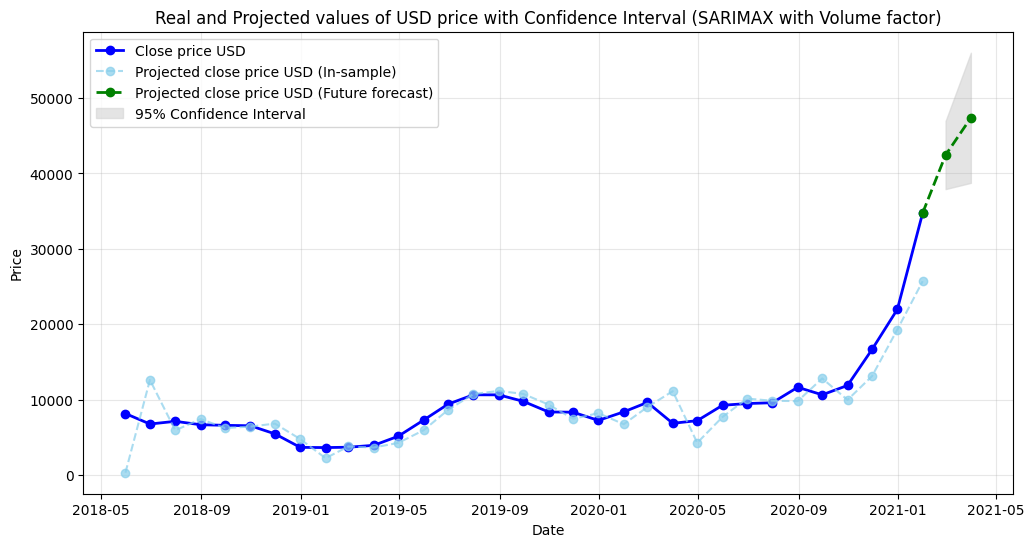

In [35]:


ts_data = digital_currency_monthly['close_USD'].asfreq('ME').interpolate(method='linear')
exog_data = digital_currency_monthly['volume'].asfreq('ME').interpolate(method='linear')


model = SARIMAX(ts_data, exog=exog_data, order=(1, 1, 0), seasonal_order=(0, 0, 0, 0))
model_fitted = model.fit(disp=False)


in_sample_preds = model_fitted.predict(start=ts_data.index[0], end=ts_data.index[-1], exog=exog_data)

real_y1 = ts_data.dropna().iloc[1:]
pred_y1 = in_sample_preds.iloc[1:]

# 4. Расчет метрик (MAE, MAPE, MASE)
mae_arimax = mean_absolute_error(real_y1, pred_y1)

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
mape_arimax = mean_absolute_percentage_error(real_y1, pred_y1)


mae_native = np.mean(np.abs(np.diff(ts_data.values)))
mase_native = mae / mae_native

mase_ar = mae/mae_ar
mase_arima = mae / mae1

print(f"Mean Absolute Error (MAE): {mae:.2f} USD")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f} %")
print(f"Mean Absolute Scaled Error (MASE) native prediction: {mase_native:.4f}")
print(f"Mean Absolute Scaled Error (MASE) AR: {mase_ar:.4f}")
print(f"Mean Absolute Scaled Error (MASE) ARIMA: {mase_arima:.4f}")


n_periods = 2
future_exog_val = exog_data.iloc[-3:].mean()
future_dates = pd.date_range(start=ts_data.index[-1] + pd.offsets.MonthEnd(), periods=n_periods, freq='ME')
future_exog = pd.DataFrame([future_exog_val] * n_periods, index=future_dates, columns=['volume'])

forecast_results = model_fitted.get_forecast(steps=n_periods, exog=future_exog)
forecast_values = forecast_results.predicted_mean
confidence_intervals = forecast_results.conf_int()


plt.figure(figsize=(12, 6))


plt.plot(ts_data.index, ts_data.values, color='blue', marker='o', label='Close price USD', linewidth=2)


plt.plot(in_sample_preds.index, in_sample_preds.values, color='skyblue', linestyle='--', marker='o', alpha=0.7, label='Projected close price USD (In-sample)')


connect_dates = [ts_data.index[-1], forecast_values.index[0], forecast_values.index[1]]
connect_values = [ts_data.values[-1], forecast_values.iloc[0], forecast_values.iloc[1]]


plt.plot(connect_dates, connect_values, color='green', linestyle='--', marker='o', label='Projected close price USD (Future forecast)', linewidth=2)


plt.fill_between(forecast_values.index,
                 confidence_intervals.iloc[:, 0],
                 confidence_intervals.iloc[:, 1],
                 color='lightgray', alpha=0.6, label='95% Confidence Interval')


plt.title('Real and Projected values of USD price with Confidence Interval (SARIMAX with Volume factor)', fontsize=12)
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')

plt.show()

### **ARIMAX Model Evaluation & Forecast Summary (with Volume Exogenous Factor)**

* **Model & Dynamics**
  An **ARIMAX(1,1,0)** model was implemented by incorporating **Volume** as an exogenous variable to predict the `close_USD` price. This approach captures both the strong autoregressive month-to-month dependency and the direct impact of market trading activity on asset pricing.

* **Accuracy Metrics Evaluation**
  The model demonstrates a strong alignment during stable market phases but exhibits minor tracking delays during exponential price surges:
  * **MAE (Mean Absolute Error):** **1,657.69 USD** — represents the average absolute deviation from actual prices.
  * **MAPE (Mean Absolute Percentage Error):** **18.35%** — confirms reasonable predictive accuracy for a highly volatile asset.
  * **MASE (Mean Absolute Scaled Error):** The metrics (**Native: 1.0466**, **AR: 1.0481**, **ARIMA: 1.0139**) hover slightly above $1.0$, indicating that historical trend patterns combined with volume metrics perform closely to a baseline naive forecast during explosive, non-linear market shifts.

* **Future Forecast & Price Projections**
  The model projects a continuous, aggressive upward trajectory for the upcoming two periods:
  * **2021-02-28:** **42,440.77 USD** *(95% CI: [37,926.54 — 46,955.01] USD)*
  * **2021-03-31:** **47,384.71 USD** *(95% CI: [38,753.44 — 56,015.97] USD)*

* **Uncertainty & Risk Analysis**
  The rapidly widening **95% Confidence Interval** in March highlights substantial statistical uncertainty. This expanding boundary emphasizes a high-risk profile and accelerating market volatility for longer-term forecasting windows.

In [45]:
model_accuracy = pd.DataFrame({'Native prediction': [mae_native, mape_native], 'Auto Regresion (AR)': [mae_ar, mape_sklearn], 'ARIMA': [mae1, mape1], 'ARIMAX': [mae_arimax, mape_arimax]}, index = ['MAE', 'MAPE'])

model_accuracy

,Native prediction,Auto Regresion (AR),ARIMA,ARIMAX
MAE,1583.946499,1581.587568,1634.938460,1657.691311
MAPE,14.053607,20.540085,17.625543,18.347842


In [48]:
total_mase = pd.DataFrame({'MASE (ARIMAX)': [mase_native, mase_ar, mase_arima]}, index = ['Native prediction', 'Auto Regresion', 'ARIMA'])

total_mase

,MASE (ARIMAX)
Native prediction,1.046558
Auto Regresion,1.048119
ARIMA,1.013917


## **Final Conclusion**

### **Study Overview & Justification**
This study investigated the dynamics of a digital asset price series using several forecasting approaches, including **Naive Forecast**, **Auto Regression (AR)**, **ARIMA**, and **ARIMAX** models.

The exploratory analysis revealed a pronounced upward trend, considerable volatility, and strong dependence between current and past observations. Autocorrelation analysis confirmed that historical values contain useful information for forecasting future price movements, making time-series models highly suitable for this dataset.

---

### **The Naive Forecast Paradox**
The forecasting results demonstrated that the **Naive Forecast achieved the lowest MAPE value** among all evaluated models. However, this result must be interpreted with caution:
* **Sensitivity to Volatility:** The final observations in the dataset contain significant fluctuations and potential outliers, which substantially influence the benchmark forecast.
* **Data-Generating Process:** Since the Naive Forecast relies exclusively on the most recent observation, its predictions are highly sensitive to abrupt changes in the series and may not adequately reflect the true underlying data-generating process.

---

### **Parametric Models Evaluation**
* **AR(1) Model:** Successfully captured the primary dependence structure of the series and produced statistically acceptable residuals.
* **ARIMA Model:** Further improved the representation of temporal dynamics by accounting for non-stationarity through differencing.
* **ARIMAX Model:** Incorporated trading volume as an exogenous variable, providing a broader view of the market factors directly affecting price behavior.

---

### **Robustness vs. Accuracy**
Although the more sophisticated models did not demonstrate a substantial improvement in forecast accuracy compared to the Naive Forecast, they offer a **more robust and theoretically justified framework** for analyzing highly volatile financial time series.

Unlike the Naive Forecast, these advanced models are less dependent on individual extreme observations and are significantly better suited for identifying persistent long-term patterns in the data.

---

### **Core Takeaways & Future Research**
* **Predictability:** The analysis confirms that digital asset prices exhibit significant temporal dependence and can be partially predicted using historical information.
* **Limitations:** The presence of high volatility, structural changes, and unexpected market events places a natural ceiling on overall forecasting accuracy.
* **Next Steps:** Future research could improve predictive performance by incorporating:
  * External market variables and macroeconomic factors
  * Investor and market sentiment indicators
  * Advanced machine learning and deep learning techniques